# AMATH 515 Homework 2

**Due Date: 02/06/2026**

* Name: Justin Chang
* Student Number: 2329407
* Favorite Color: BLUE

*Homework Instruction*: Please follow order of this notebook and fill in the codes where commented as `TODO`.

In [10]:
import numpy as np
import numpy.linalg as LA
import scipy.io as sio
import matplotlib.pyplot as plt

## Please complete the solvers in `solver.py`

In [11]:
import sys

sys.path.append('./')
from solvers import *

## Problem 3: Compressive Sensing

Consier the optimization problem,

$$
\min_x~~\frac{1}{2}\|Ax - b\|^2 + \lambda\|x\|_1
$$

In the following, please specify the $f$ and $g$ and use the proximal gradient descent solver to obtain the solution.

In [12]:
# create the data
np.random.seed(123)
m = 100  # number of measurements
n = 500  # number of variables
k = 10  # number of nonzero variables
s = 0.05  # measurements noise level
#
A_cs = np.random.randn(m, n)
x_cs = np.zeros(n)
x_cs[np.random.choice(range(n), k, replace=False)] = np.random.choice([-1.0, 1.0], k)
b_cs = A_cs.dot(x_cs) + s * np.random.randn(m)
#
lam_cs = 0.1 * norm(A_cs.T.dot(b_cs), np.inf)

In [13]:
# define the function, prox and the beta constant
def func_f_cs(x):
    f = 0.5 * (LA.norm(A_cs @ x - b_cs, 2)) ** 2
    return f


def func_g_cs(x):
    g = lam_cs * LA.norm(x, 1)
    return g


def grad_f_cs(x):
    grad = A_cs.T @ (A_cs @ x - b_cs)
    return grad


def prox_g_cs(z, t):
    ## z is the gradient step
    ## t = 1/ beta
    x_kp1 = np.zeros_like(z)
    for i in range(len(z)):
        if z[i] > t * lam_cs:
            x_kp1[i] = z[i] - t * lam_cs
        elif np.abs(z[i]) <= t * lam_cs:
            x_kp1[i] = 0
        else:
            x_kp1[i] = t * lam_cs + z[i]

    return x_kp1


# TODO: complete the prox of 1 norm

##==GRADED==##
# TODO: what is the beta value for the smooth part
beta_f_cs = LA.norm(A_cs.T @ A_cs, 2)

In [14]:
##==GRADED==##
cs_test_dot = np.ones(n)

# Should be a number
func_cs_test = func_f_cs(cs_test_dot) + func_g_cs(cs_test_dot)

# Should be a numpy vector of shape (n, )
grad_f_cs_test = grad_f_cs(cs_test_dot)

# Should be a numpy vector of shape (n, )
prox_g_cs_test = prox_g_cs(cs_test_dot, 1)

### Proximal gradient descent on compressive sensing

In [15]:
# apply the proximal gradient descent solver
x0_cs_pgd = np.zeros(x_cs.size)
x_cs_pgd, obj_his_cs_pgd, err_his_cs_pgd, exit_flag_cs_pgd = optimizeWithPGD(x0_cs_pgd, func_f_cs, func_g_cs, grad_f_cs,
                                                                             prox_g_cs, beta_f_cs)

solver begin


Text(0.5, 1.0, 'Compressive Sensing Signal')

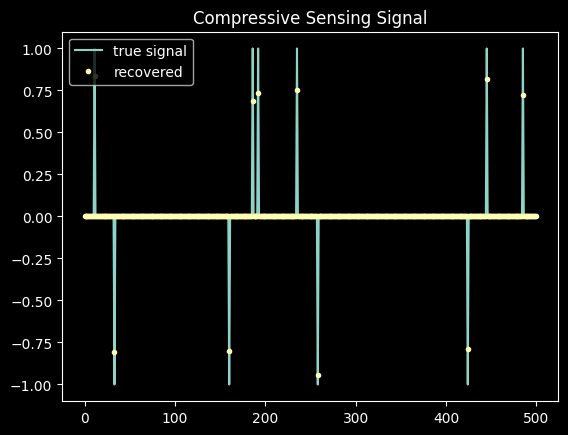

In [16]:
# plot signal result
plt.plot(x_cs)
plt.plot(x_cs_pgd, '.')
plt.legend(['true signal', 'recovered'])
plt.title('Compressive Sensing Signal')

Text(0.5, 0.98, 'Proximal Gradient Descent on Compressive Sensing')

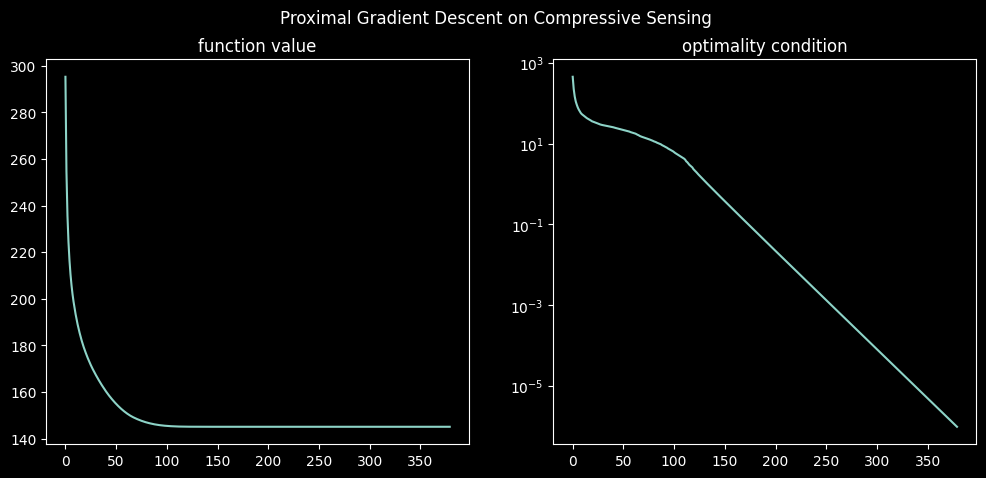

In [17]:
# plot result
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(obj_his_cs_pgd)
ax[0].set_title('function value')
ax[1].semilogy(err_his_cs_pgd)
ax[1].set_title('optimality condition')
fig.suptitle('Proximal Gradient Descent on Compressive Sensing')

### Accelerate proximal gradient descent on compressive sensing

In [19]:
# apply the proximal gradient descent solver
x0_cs_apgd = np.zeros(x_cs.size)
x_cs_apgd, obj_his_cs_apgd, err_his_cs_apgd, exit_flag_cs_apgd = \
    optimizeWithAPGD(x0_cs_apgd, func_f_cs, func_g_cs, grad_f_cs, prox_g_cs, beta_f_cs)

NameError: name 'optimizeWithAPGD' is not defined

In [ ]:
# plot signal result
plt.plot(x_cs)
plt.plot(x_cs_pgd, '.')
plt.legend(['true signal', 'recovered'])
plt.title('Compressive Sensing Signal')

In [ ]:
# plot result
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(obj_his_cs_apgd)
ax[0].set_title('function value')
ax[1].semilogy(err_his_cs_apgd)
ax[1].set_title('optimality condition')
fig.suptitle('Accelerated Proximal Gradient Descent on Compressive Sensing')

## Problem 4: Logistic Regression on MNIST Data

Now let's play with some real data, recall the logistic regression problem,

$$
\min_x~~\sum_{i=1}^m\left\{\log(1 + \exp(\langle a_i,x \rangle)) - b_i\langle a_i,x \rangle\right\} + \frac{\lambda}{2}\|x\|^2.
$$

Here our data pair $\{a_i, b_i\}$, $a_i$ is the image and $b_i$ is the label.
In this homework problem, let's consider the binary classification problem, where $b_i \in \{0, 1\}$.

In [ ]:
# import data
mnist_data = np.load('mnist01.npy', allow_pickle=True)
#
A_lgt = mnist_data[0]
b_lgt = mnist_data[1]
A_lgt_test = mnist_data[2]
b_lgt_test = mnist_data[3]
#
# set regularizer parameter
lam_lgt = 0.1
#
# beta constant of the function
beta_lgt = 0.25 * norm(A_lgt, 2) ** 2 + lam_lgt


# define accuracy function
def accuracy(x, A_test, b_test):
    r = A_test.dot(x)
    b_test[b_test == 0.0] = -1.0
    correct_count = np.sum((r * b_test) > 0.0)
    return correct_count / b_test.size

In [ ]:
# plot the images
fig, ax = plt.subplots(1, 2)
ax[0].imshow(A_lgt[0].reshape(28, 28))
ax[1].imshow(A_lgt[7].reshape(28, 28))

In [ ]:
# Define the loss function, its gradient and Hessian
# Hint: you can just copy it from your Homework 1. 

def lgt_func(x):


# TODO: complete the function of logistic regression

def lgt_grad(x):


# TODO: complete the gradient of logistic regression

def lgt_hess(x):

# TODO: complete the hessian of logistic regression


### Gradient descent on logistic regression

In [ ]:
# apply the gradient descent
x0_lgt_gd = np.zeros(A_lgt.shape[1])
x_lgt_gd, obj_his_lgt_gd, err_his_lgt_gd, exit_flag_lgt_gd = \
    optimizeWithGD(x0_lgt_gd, lgt_func, lgt_grad, beta_lgt)

In [ ]:
print('accuracy of the result is %0.3f' % accuracy(x_lgt_gd, A_lgt_test, b_lgt_test))
# plot result
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(obj_his_lgt_gd)
ax[0].set_title('function value')
ax[1].semilogy(err_his_lgt_gd)
ax[1].set_title('optimality condition')
fig.suptitle('Gradient Descent on Logistic Regression')

### Accelerate Gradient decsent on logistic regression

In [ ]:
# apply the accelerated gradient descent
x0_lgt_agd = np.zeros(A_lgt.shape[1])
x_lgt_agd, obj_his_lgt_agd, err_his_lgt_agd, exit_flag_lgt_agd = \
    optimizeWithAGD(x0_lgt_agd, lgt_func, lgt_grad, beta_lgt)

In [ ]:
print('accuracy of the result is %0.3f' % accuracy(x_lgt_agd, A_lgt_test, b_lgt_test))
# plot result
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(obj_his_lgt_agd)
ax[0].set_title('function value')
ax[1].semilogy(err_his_lgt_agd)
ax[1].set_title('optimality condition')
fig.suptitle('Accelerated Gradient Descent on Logistic Regression')

### Newton Method on logistic regression

In [ ]:
# apply the accelerated gradient descent
x0_lgt_nt = np.zeros(A_lgt.shape[1])
x_lgt_nt, obj_his_lgt_nt, err_his_lgt_nt, exit_flag_lgt_nt = \
    optimizeWithNT(x0_lgt_nt, lgt_func, lgt_grad, lgt_hess)

In [ ]:
print('accuracy of the result is %0.3f' % accuracy(x_lgt_nt, A_lgt_test, b_lgt_test))
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(obj_his_lgt_nt)
ax[0].set_title('function value')
ax[1].semilogy(err_his_lgt_nt)
ax[1].set_title('optimality condition')
fig.suptitle('Newton\'s Method on Logistic Regression')

plt.show()
plt.title("Coefficient for each pixel")
plt.imshow(x_lgt_nt.reshape(28, 28))
plt.colorbar()
plt.show()

## We can combine the compressed sensing (lasso) regularizer with the logistic regression objective to get a sparse classifier

In [ ]:
# apply the proximal gradient descent solver
x0_mnist_pgd = np.zeros(A_lgt.shape[1])
x_mnist_pgd, obj_his_mnist_apgd, err_his_mnist_apgd, exit_flag_mnist_pgd = \
    optimizeWithAPGD(x0_mnist_pgd, lgt_func, func_g_cs, lgt_grad, prox_g_cs, beta_lgt)

print(f"Classifying looking at {np.sum(x_mnist_pgd != 0)} nonzero entries")
print('accuracy of the result is %0.3f' % accuracy(x_lgt_nt, A_lgt_test, b_lgt_test))
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(obj_his_mnist_apgd)
ax[0].set_title('function value')
ax[1].semilogy(err_his_mnist_apgd)
ax[1].set_title('optimality condition')
fig.suptitle('APGD on Logistic Regression')
plt.show()

plt.title("Coefficient for each pixel")
plt.imshow(x_mnist_pgd.reshape(28, 28))
plt.colorbar()
plt.show()
